AIM: To build and evaluate a Linear Regressor model for Bike Sharing Prediction System
and study the effect of 70-30 and 80-20 data splitting.
Name: Vaishnavi Sandokar
USN: CS24D007

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/ML /day.csv"   # change if needed
df = pd.read_csv(path)

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
df.shape

(731, 16)

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
# Drop unnecessary columns
df = df.drop(['instant', 'dteday'], axis=1)

# Avoid data leakage
df = df.drop(['casual', 'registered'], axis=1)

df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [ ]:
X = df.drop('cnt', axis=1)
y = df['cnt']

print(X.shape)
print(y.shape)

(731, 11)
(731,)


In [ ]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_70 = scaler.fit_transform(X_train_70)
X_test_30 = scaler.transform(X_test_30)

In [ ]:
model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)

LinearRegression()

In [ ]:
y_pred_70 = model_70.predict(X_test_30)

In [ ]:
mae_70 = mean_absolute_error(y_test_30, y_pred_70)
mse_70 = mean_squared_error(y_test_30, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_30, y_pred_70)

print("70-30 Results")
print("MAE:", mae_70)
print("MSE:", mse_70)
print("RMSE:", rmse_70)
print("R2 Score:", r2_70)

70-30 Results
MAE: 636.3813583812837
MSE: 751126.2310636702
RMSE: 866.6753896723214
R2 Score: 0.811225776607647


In [ ]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_80 = scaler.fit_transform(X_train_80)
X_test_20 = scaler.transform(X_test_20)

In [ ]:
model_80 = LinearRegression()
model_80.fit(X_train_80, y_train_80)

LinearRegression()

In [ ]:
y_pred_80 = model_80.predict(X_test_20)

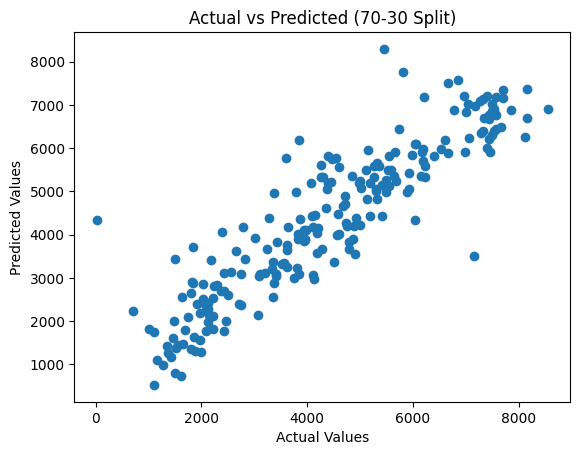

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test_30, y_pred_70)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (70-30 Split)")
plt.show()

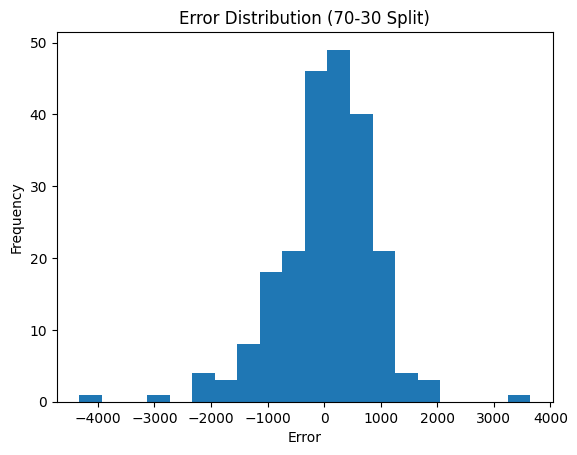

In [ ]:
errors_70 = y_test_30 - y_pred_70

plt.hist(errors_70, bins=20)
plt.title("Error Distribution (70-30 Split)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

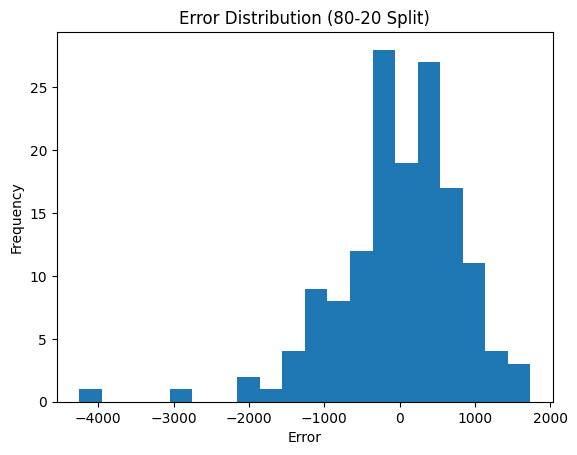

In [ ]:
errors_80 = y_test_20 - y_pred_80

plt.hist(errors_80, bins=20)
plt.title("Error Distribution (80-20 Split)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

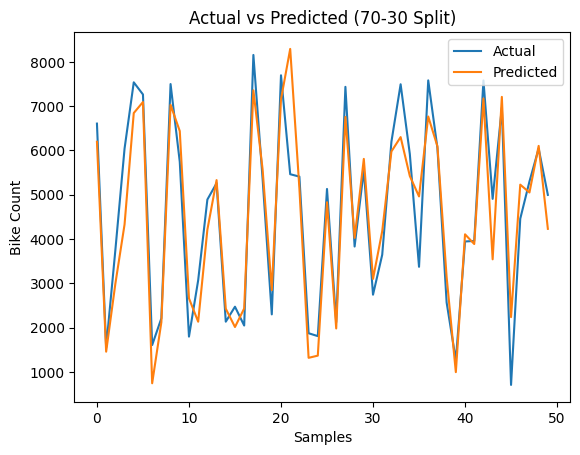

In [ ]:
plt.plot(y_test_30.values[:50], label="Actual")
plt.plot(y_pred_70[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (70-30 Split)")
plt.xlabel("Samples")
plt.ylabel("Bike Count")
plt.show()

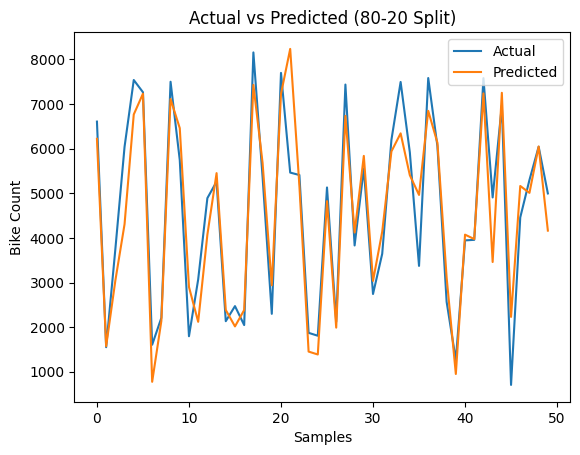

In [ ]:
plt.plot(y_test_20.values[:50], label="Actual")
plt.plot(y_pred_80[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (80-20 Split)")
plt.xlabel("Samples")
plt.ylabel("Bike Count")
plt.show()